# spark initiation

In [1]:
!pip install pyspark -q
!apt-get install openjdk-17-jdk-headless -qq > /dev/null

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [2]:
spark = (
    SparkSession.builder
    .appName("BT4221_HDB_Resale_Prices_Project")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

print("Spark version:", spark.version)

spark.sparkContext.setLogLevel("WARN")

Spark version: 4.0.2


# Load data set

Modeled from DataGovSG sample code

In [21]:
import time
import requests
from pyspark.sql.window import Window
from google.colab import userdata
from pyspark.sql.types import (
    StructType, StructField,
    StringType, DoubleType, IntegerType
)

API_KEY  = userdata.get("GOV_DATA")

PRICE_DATASETS = [
    {"id": "d_8b84c4ee58e3cfc0ece0d773c8ca6abc", "label": "2017-present"},
    {"id": "d_ea9ed51da2787afaf8e51f827c304208", "label": "2015-2016"},
    {"id": "d_2d5ff9ea31397b66239f245f57751537", "label": "Mar2012-2014"},
    {"id": "d_43f493c6c50d54243cc1eab0df142d6a", "label": "2000-Feb2012"},
]

# fixed schema
PRICE_SCHEMA = StructType([
    StructField("month",               StringType(),  True),  # YYYY-MM
    StructField("town",                StringType(),  True),
    StructField("flat_type",           StringType(),  True),
    StructField("block",               StringType(),  True),
    StructField("street_name",         StringType(),  True),
    StructField("storey_range",        StringType(),  True),  # e.g. "07 TO 09"
    StructField("floor_area_sqm",      DoubleType(),  True),
    StructField("flat_model",          StringType(),  True),
    StructField("lease_commence_date", IntegerType(), True),  # YYYY
    StructField("remaining_lease",     StringType(),  True),  # e.g. "61 years 04 months"
    StructField("resale_price",        DoubleType(),  True),
    StructField("_source",             StringType(),  True),
])

def align_to_schema(df, label):
    """
    Align any dataset to the canonical schema regardless of which
    columns are present. Missing columns are added as null.
    Casts are applied after alignment so types are always consistent.
    """

    # Normalise column names to lowercase + underscores to match schema
    for col in df.columns:
        clean = col.strip().lower().replace(" ", "_")
        if clean != col:
            df = df.withColumnRenamed(col, clean)

    # Add missing columns as null
    canonical_cols = [
        "month", "town", "flat_type", "block", "street_name",
        "storey_range", "floor_area_sqm", "flat_model",
        "lease_commence_date", "remaining_lease", "resale_price"
    ]
    for col in canonical_cols:
        if col not in df.columns:
            print(f"    [{label}] '{col}' not found — adding as null")
            df = df.withColumn(col, F.lit(None).cast(StringType()))

    # Cast numeric columns safely after all columns are present
    df = (
        df
        .withColumn("floor_area_sqm",
                    F.when(F.col("floor_area_sqm").rlike(r"^-?\d+(\.\d+)?$"),
                           F.col("floor_area_sqm").cast(DoubleType()))
                    .otherwise(F.lit(None).cast(DoubleType())))
        .withColumn("lease_commence_date",
                    F.when(F.col("lease_commence_date").rlike(r"^\d+$"),
                           F.col("lease_commence_date").cast(IntegerType()))
                    .otherwise(F.lit(None).cast(IntegerType())))
        .withColumn("resale_price",
                    F.when(F.col("resale_price").rlike(r"^-?\d+(\.\d+)?$"),
                           F.col("resale_price").cast(DoubleType()))
                    .otherwise(F.lit(None).cast(DoubleType())))
    )

    # Keep only canonical columns + source tag in consistent order
    df = df.select(canonical_cols).withColumn("_source", F.lit(label))
    return df


s = requests.Session()
s.headers.update({
    "referer":   "https://colab.research.google.com",
    "x-api-key": API_KEY,
})

def download_dataset(dataset_id, label, schema, max_polls=10):
    print(f"  [{label}]  initiating download...")

    s.get(
        f"https://api-open.data.gov.sg/v1/public/api/datasets/{dataset_id}/initiate-download",
        json={}
    )

    for i in range(max_polls):
        poll = s.get(
            f"https://api-open.data.gov.sg/v1/public/api/datasets/{dataset_id}/poll-download",
            json={}
        ).json()

        if "url" in poll["data"]:
            url = poll["data"]["url"]
            print(f"    ready, downloading...")

            lines = requests.get(url).text.splitlines()
            rdd   = spark.sparkContext.parallelize(lines)
            df    = (spark.read
                         .option("header", "true")
                         .csv(rdd))
            df = df.withColumn("_source", F.lit(label))

            # Align to canonical schema — adds missing columns as null,
            # casts existing columns to correct types
            df = align_to_schema(df, label)
            print(f"    done ✓  ({df.count():,} rows)")
            return df

        print(f"    poll {i+1}/{max_polls}: not ready yet...")
        time.sleep(3)

    raise TimeoutError(f"Dataset {label} never became ready after {max_polls} polls")

def load_from_api(dfs, schema):
    dfs = [download_dataset(ds["id"], ds["label"], schema) for ds in dfs]

    # Union all 4 DataFrames
    from functools import reduce
    combined = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs)

    print(f"\n  Total rows loaded: {combined.count():,}")
    return combined

In [22]:
prices_df = load_from_api(PRICE_DATASETS,PRICE_SCHEMA)

  [2017-present]  initiating download...
    ready, downloading...
    done ✓  (226,916 rows)
  [2015-2016]  initiating download...
    ready, downloading...
    done ✓  (37,153 rows)
  [Mar2012-2014]  initiating download...
    ready, downloading...
    [Mar2012-2014] 'remaining_lease' not found — adding as null
    done ✓  (52,203 rows)
  [2000-Feb2012]  initiating download...
    ready, downloading...
    [2000-Feb2012] 'remaining_lease' not found — adding as null
    done ✓  (369,651 rows)

  Total rows loaded: 685,923


In [23]:
prices_df.printSchema()

root
 |-- month: string (nullable = true)
 |-- town: string (nullable = true)
 |-- flat_type: string (nullable = true)
 |-- block: string (nullable = true)
 |-- street_name: string (nullable = true)
 |-- storey_range: string (nullable = true)
 |-- floor_area_sqm: double (nullable = true)
 |-- flat_model: string (nullable = true)
 |-- lease_commence_date: integer (nullable = true)
 |-- remaining_lease: string (nullable = true)
 |-- resale_price: double (nullable = true)
 |-- _source: string (nullable = false)



In [25]:
prices_df.filter(F.col("_source") == "2000-Feb2012").show(10)

+-------+----------+---------+-----+----------------+------------+--------------+--------------+-------------------+---------------+------------+------------+
|  month|      town|flat_type|block|     street_name|storey_range|floor_area_sqm|    flat_model|lease_commence_date|remaining_lease|resale_price|     _source|
+-------+----------+---------+-----+----------------+------------+--------------+--------------+-------------------+---------------+------------+------------+
|2000-01|ANG MO KIO|   3 ROOM|  170|ANG MO KIO AVE 4|    07 TO 09|          69.0|      Improved|               1986|           NULL|    147000.0|2000-Feb2012|
|2000-01|ANG MO KIO|   3 ROOM|  174|ANG MO KIO AVE 4|    04 TO 06|          61.0|      Improved|               1986|           NULL|    144000.0|2000-Feb2012|
|2000-01|ANG MO KIO|   3 ROOM|  216|ANG MO KIO AVE 1|    07 TO 09|          73.0|New Generation|               1976|           NULL|    159000.0|2000-Feb2012|
|2000-01|ANG MO KIO|   3 ROOM|  215|ANG MO KIO

# cleaning agent





In [7]:
!pip install -q langgraph langchain langchain-openai matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 3.8 MB/s eta 0:00:00


In [8]:
import json
import openai
from pyspark.sql.types import (
    StringType, LongType,
    FloatType, DateType, TimestampType
)
NUMERIC_TYPES = (DoubleType, FloatType, IntegerType, LongType)

In [9]:
client = openai.OpenAI(api_key=userdata.get("BT4221_OPENAI_API_KEY"))
MAX_RETRIES = 2

CLEANING TOOLS

In [31]:
def tool_trim_uppercase(sdf, column, **kwargs):
    """Trim whitespace and upper-case a string column."""
    return sdf.withColumn(column, F.upper(F.trim(F.col(column))))

def tool_parse_yyyymm_date(sdf, column, **kwargs):
    """
    Parse a YYYY-MM string column into a DateType column (first of month).
    Replaces the original column in-place.
    """
    return sdf.withColumn(
        column,
        F.to_date(F.concat(F.col(column), F.lit("-01")), "yyyy-MM-dd")
    )

def tool_parse_yyyymmdd_date(sdf, column, **kwargs):
    """Parse a YYYY-MM-DD string column into a DateType column."""
    return sdf.withColumn(column, F.to_date(F.col(column), "yyyy-MM-dd"))

def tool_parse_lease_string(sdf, column, **kwargs):
    """
    Parse remaining_lease string → numeric years, replacing the original column.
    Handles: '61 years 04 months', '62 years 01 month', '63 years'
    """
    years = F.nullif(
        F.regexp_extract(F.col(column), r"(\d+)\s*[Yy]ear", 1), F.lit("")
    ).cast(DoubleType())

    months = F.coalesce(
        F.nullif(F.regexp_extract(F.col(column), r"(\d+)\s*[Mm]onth", 1), F.lit(""))
         .cast(DoubleType()),
        F.lit(0.0)
    )
    # Replace original column
    return sdf.withColumn(column, F.coalesce(years, F.lit(None).cast(DoubleType())) + months / 12.0)

def tool_drop_nulls(sdf, column, **kwargs):
    """Drop rows where the specified column is null or empty string."""
    return sdf.filter(
        F.col(column).isNotNull() & (F.trim(F.col(column).cast("string")) != "")
    )

def tool_flag_outliers_zscore(sdf, column, group_by=None, threshold=4.0, **kwargs):
    """
    Add a boolean column {column}_outlier flagging rows where the z-score
    of `column` exceeds `threshold` (default 4.0).
    If group_by is provided, z-score is computed within each group.
    Rows are flagged, NOT removed.
    """
    out_col = column + "_outlier"
    w = Window.partitionBy(group_by) if group_by else Window.rowsBetween(
        Window.unboundedPreceding, Window.unboundedFollowing
    )
    return (
        sdf
        .withColumn("_mean", F.mean(column).over(w))
        .withColumn("_std",  F.stddev(column).over(w))
        .withColumn(
            out_col,
            F.when(
                F.col("_std") > 0,
                F.abs(F.col(column) - F.col("_mean")) / F.col("_std") > threshold
            ).otherwise(F.lit(False))
        )
        .drop("_mean", "_std")
    )

def tool_standardise_values(sdf, column, replacements, **kwargs):
    """
    Replace inconsistent string values in a column.
    `replacements` is a dict: {"old_value": "new_value", ...}
    e.g. {"MULTI GENERATION": "MULTI-GENERATION", "MULTI-GEN": "MULTI-GENERATION"}
    """
    for old, new in replacements.items():
        sdf = sdf.withColumn(
            column,
            F.when(F.col(column) == old, F.lit(new)).otherwise(F.col(column))
        )
    return sdf

def tool_impute_remaining_lease(sdf, column, **kwargs):
    """
    Impute missing remaining_lease values using:
        99 - (transaction_year - lease_commence_date)
    Only fills nulls — existing values are preserved.
    Requires: lease_commence_date (int) and month (YYYY-MM string) to be present.
    """
    sale_year = F.year(F.to_date(F.concat(F.col("month"), F.lit("-01")), "yyyy-MM-dd"))
    approximated = (99 - (sale_year - F.col("lease_commence_date"))).cast(DoubleType())

    return sdf.withColumn(
        column,
        F.coalesce(F.col(column), approximated)   # keep existing, fill nulls
    )

In [32]:
# Registry — maps tool name (string) → function
TOOL_REGISTRY = {
    "trim_uppercase":       tool_trim_uppercase,
    "parse_yyyymm_date":    tool_parse_yyyymm_date,
    "parse_yyyymmdd_date":  tool_parse_yyyymmdd_date,
    "parse_lease_string":   tool_parse_lease_string,
    "drop_nulls":           tool_drop_nulls,
    "flag_outliers_zscore": tool_flag_outliers_zscore,
    "standardise_values":   tool_standardise_values,
    "impute_remaining_lease": tool_impute_remaining_lease,
}

TOOL_CATALOGUE = """
Available cleaning tools (name → what it does → required args → optional args):
  trim_uppercase        → trim whitespace and upper-case a string column
                          args: column
  parse_yyyymm_date     → parse YYYY-MM string → DateType (first of month)
                          args: column
  parse_yyyymmdd_date   → parse YYYY-MM-DD string → DateType
                          args: column
  parse_lease_string    → extract years from '61 years 04 months' or plain '61'
                          → new column {col}_years (double)
                          args: column
  drop_nulls            → drop rows where column is null or empty
                          args: column
  flag_outliers_zscore  → add {col}_outlier boolean (z-score > threshold, default 4.0)
                          args: column   optional: group_by (column name), threshold (float)
  standardise_values    → replace inconsistent string values
                          args: column, replacements (dict of old→new)
  impute_remaining_lease → fill null remaining_lease values using
                           99 - (sale_year - lease_commence_date)
                           args: column
                           requires: month and lease_commence_date columns
"""

PROFILER

dataset info for llm to plan

In [34]:
def profile_dataframe(sdf):
    total       = sdf.count()
    sample_rows = sdf.limit(3).collect()

    # Header
    lines = [
        f"Total rows: {total:,}",
        "",
        f"{'Column':<25} {'Type':<15} {'Nulls':>8} {'Distinct':>10}  {'Patterns':<30}  {'Samples'}",
        "-" * 110
    ]

    for field in sdf.schema.fields:
        col   = field.name
        dtype = str(field.dataType)

        # Nulls
        if isinstance(field.dataType, StringType):
            null_n = sdf.filter(F.col(col).isNull() | (F.trim(F.col(col)) == "")).count()
        else:
            null_n = sdf.filter(F.col(col).isNull()).count()
        null_str = f"{null_n/total*100:.0f}%" if null_n > 0 else "0%"

        # Distinct
        distinct_n = sdf.select(col).distinct().count()

        # Patterns (string only)
        patterns = ""
        if isinstance(field.dataType, StringType):
            non_null   = sdf.filter(F.col(col).isNotNull() & (F.trim(F.col(col)) != ""))
            non_null_n = non_null.count()
            if non_null_n > 0:
                def pct(pattern):
                    return non_null.filter(F.col(col).rlike(pattern)).count() / non_null_n * 100
                checks = [
                    ("YYYY-MM",   pct(r"^\d{4}-\d{2}$")),
                    ("X TO Y",    pct(r"^\d+ TO \d+$")),
                    ("unit str",  pct(r"\d+\s*(year|month)")),
                ]
                patterns = "  ".join(f"{label}:{v:.0f}%" for label, v in checks if v > 10)

        # Numeric stats
        if isinstance(field.dataType, NUMERIC_TYPES):
            s = sdf.select(F.min(col), F.max(col)).collect()[0]
            patterns = f"min={s[0]}  max={s[1]}"

        # Samples
        samples = ", ".join(str(r[col]) for r in sample_rows if r[col] is not None)[:50]

        lines.append(
            f"{col:<25} {dtype:<15} {null_str:>8} {distinct_n:>10}  {patterns:<30}  {samples}"
        )

    return "\n".join(lines)

LLM helper

In [38]:
def ask_llm_for_plan(profile_str):
    prompt = f"""You are a data cleaning expert. You have a set of predefined
cleaning tools and a DataFrame profile. Your job is to decide which tools
to apply to which columns.

{TOOL_CATALOGUE}

DATAFRAME PROFILE:
{profile_str}

Rules:
  - Only call a tool if the profile clearly justifies it
  - Numeric columns (DoubleType, IntegerType) are already correctly typed — do not cast them
  - Only apply tools to columns where the profile shows a clear need
  - Do not add year/quarter if they already exist as columns
  - For flag_outliers_zscore on a price column, set group_by to the most
    appropriate categorical column (e.g. flat_type)
  - For trim_uppercase, apply to all string columns that contain categorical
    text (e.g. town, flat_type, flat_model, street_name, block)
  - For parse_lease_string, only call if the column is StringType and contains
    lease duration text — do not call on numeric columns
  - For remaining_lease, always call impute_remaining_lease AFTER parse_lease_string
    to fill any nulls (e.g. pre-2015 data that has no remaining_lease values)
  - Do NOT suggest any null handling for remaining_lease — impute_remaining_lease
    handles it automatically
  - Null handling for all other columns will be decided by the human separately —
    do not add drop_nulls or fill_null_* to the plan
  - Order matters:
      1. trim_uppercase on string columns first
      2. parse_yyyymm_date before derive_year_quarter
      3. parse_lease_string before impute_remaining_lease
      4. cast/parse before flagging outliers

Return ONLY valid JSON, no markdown:
{{
  "plan": [
    {{
      "tool": "tool_name",
      "column": "column_name",
      "kwargs": {{}},
      "reason": "one sentence referencing the profile"
    }}
  ]
}}"""

    resp = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1,
    )
    raw = resp.choices[0].message.content.strip()
    if raw.startswith("```"):
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]
    return json.loads(raw)["plan"]


def ask_llm_to_fix(error_type, error_msg, failed_call, profile_str):
    prompt = f"""A cleaning tool call has failed. Revise the arguments to fix it.

FAILED CALL:
{json.dumps(failed_call, indent=2)}

ERROR TYPE   : {error_type}
ERROR MESSAGE: {error_msg}

{TOOL_CATALOGUE}

DATAFRAME PROFILE:
{profile_str}

Rules:
  - Revise only the arguments of the failed call — do not change the intent
  - If the column type is wrong for the tool, suggest the correct tool instead
  - Do not suggest null handling tools — those are handled separately by the human
  - Do not suggest impute_remaining_lease unless the original call was already
    related to remaining_lease

Return ONLY valid JSON, no markdown:
{{
  "diagnosis": "one sentence root cause",
  "revised_call": {{
    "tool": "tool_name",
    "column": "column_name",
    "kwargs": {{}}
  }}
}}"""

    resp = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
    )
    raw = resp.choices[0].message.content.strip()
    if raw.startswith("```"):
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]
    return json.loads(raw)

PIPELINE

In [39]:
print("\nStep 1: Profiling DataFrame...")
profile_str = profile_dataframe(prices_df)
print(profile_str)

print("\nStep 2: Asking LLM to build cleaning plan...")
plan = ask_llm_for_plan(profile_str)

print(f"\nLLM plan - {len(plan)} tool calls:")
for i, call in enumerate(plan, 1):
    kwargs_str = f"  kwargs={call['kwargs']}" if call.get("kwargs") else ""
    print(f"  {i}. {call['tool']}({call['column']}){kwargs_str}")
    print(f"     → {call['reason']}")

fix_log     = []
current_sdf = prices_df     #prices only for now

print("\nStep 3: Executing plan...")
print("=" * 52)

for call in plan:
    tool_name   = call["tool"]
    column      = call["column"]
    kwargs      = call.get("kwargs", {})
    current_call = call.copy()

    print(f"\n  {tool_name}({column})")

    if tool_name not in TOOL_REGISTRY:
        print(f"  SKIPPED - unknown tool '{tool_name}'")
        continue

    success = False

    for attempt in range(1, MAX_RETRIES + 2):
        try:
            result_sdf = TOOL_REGISTRY[tool_name](current_sdf, column, **kwargs)
            result_sdf.count()   # force Spark evaluation

            print(f"  Attempt {attempt}: PASSED")
            current_sdf = result_sdf
            success = True
            break

        except Exception as e:
            err_type = type(e).__name__
            err_msg  = str(e)[:300]
            print(f"  Attempt {attempt}: FAILED  ({err_type}: {err_msg[:80]})")

            if attempt > MAX_RETRIES:
                print("  Max retries reached. Skipping.")
                break

            print("  Asking LLM to revise call...")
            llm_result   = ask_llm_to_fix(err_type, err_msg, current_call, profile_str)
            diagnosis    = llm_result.get("diagnosis", "Unknown")
            revised      = llm_result.get("revised_call", {})
            tool_name    = revised.get("tool", tool_name)
            column       = revised.get("column", column)
            kwargs       = revised.get("kwargs", kwargs)
            current_call = revised

            print(f"  Diagnosis    : {diagnosis}")
            print(f"  Revised call : {tool_name}({column}) kwargs={kwargs}")

            fix_log.append({
                "original": call,
                "attempt":  attempt,
                "error":    err_msg[:150],
                "diagnosis": diagnosis,
                "revised":  revised,
            })

    if not success:
        print(f"  Could not complete after {MAX_RETRIES} retries.")



Step 1: Profiling DataFrame...
Total rows: 685,923

Column                    Type               Nulls   Distinct  Patterns                        Samples
--------------------------------------------------------------------------------------------------------------
month                     StringType()          0%        315  YYYY-MM:100%                    2017-01, 2017-01, 2017-01
town                      StringType()          0%         26                                  ANG MO KIO, ANG MO KIO, ANG MO KIO
flat_type                 StringType()          0%          7                                  2 ROOM, 3 ROOM, 3 ROOM
block                     StringType()          0%       2755                                  406, 108, 602
street_name               StringType()          0%        584                                  ANG MO KIO AVE 10, ANG MO KIO AVE 4, ANG MO KIO AV
storey_range              StringType()          0%         25  X TO Y:100%                     10 TO 12, 01 T

In [41]:
print("PIPELINE FINISHED")
print(f"Total automatic revisions: {len(fix_log)}")

print("\nFINAL SCHEMA")
current_sdf.printSchema()

print("\nFINAL SAMPLE")
current_sdf.show(5, truncate=False)

if fix_log:
    print("\nFIX LOG")
    print("-" * 52)
    for i, fix in enumerate(fix_log, 1):
        orig = fix["original"]
        print(f"\nRevision {i} — {orig['tool']}({orig['column']})  attempt {fix['attempt']}")
        print(f"  Error    : {fix['error']}")
        print(f"  Diagnosis: {fix['diagnosis']}")
        print(f"  Revised  : {fix['revised']}")

clean_df = current_sdf
print(f"\nclean_df ready: {clean_df.count():,} rows, {len(clean_df.columns)} columns")

PIPELINE FINISHED
Total automatic revisions: 0

FINAL SCHEMA
root
 |-- month: string (nullable = true)
 |-- town: string (nullable = true)
 |-- flat_type: string (nullable = true)
 |-- block: string (nullable = true)
 |-- street_name: string (nullable = true)
 |-- storey_range: string (nullable = true)
 |-- floor_area_sqm: double (nullable = true)
 |-- flat_model: string (nullable = true)
 |-- lease_commence_date: integer (nullable = true)
 |-- remaining_lease: double (nullable = true)
 |-- resale_price: double (nullable = true)
 |-- _source: string (nullable = false)
 |-- resale_price_outlier: boolean (nullable = true)


FINAL SAMPLE
+-------+-----------+---------+-----+------------------+------------+--------------+----------+-------------------+------------------+------------+------------+--------------------+
|month  |town       |flat_type|block|street_name       |storey_range|floor_area_sqm|flat_model|lease_commence_date|remaining_lease   |resale_price|_source     |resale_price_ou

# EDA

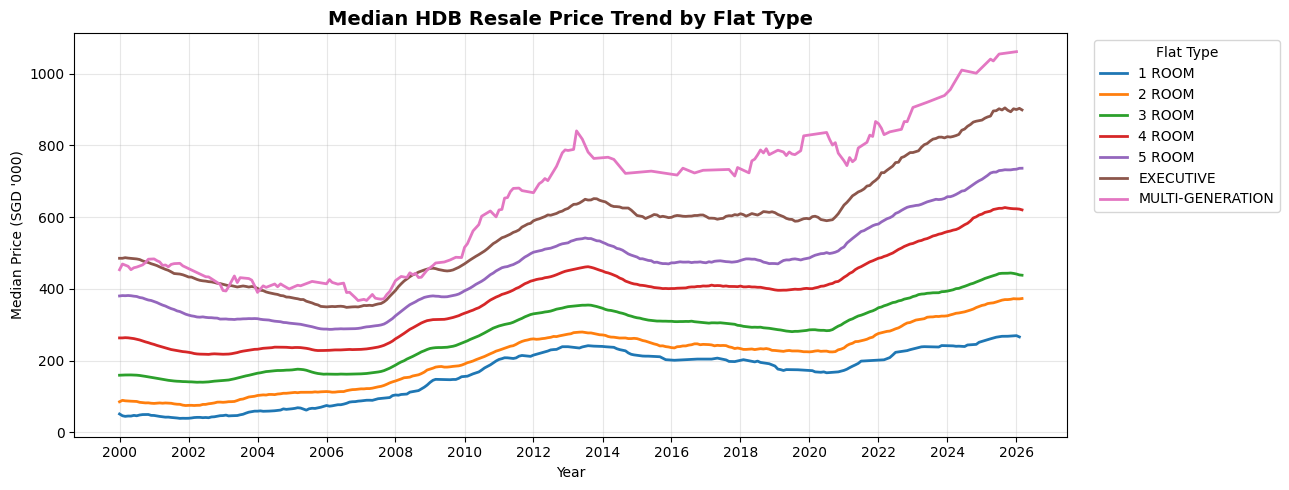

In [50]:
# ── EDA 1: Price trends over time ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = clean_df

trend_pdf = (
    df.filter(~F.col("resale_price_outlier"))
      .groupBy("month", "flat_type")
      .agg(F.percentile_approx("resale_price", 0.5).alias("median_price"))
      .toPandas()
)

trend_pdf["month"] = pd.to_datetime(trend_pdf["month"])
trend_pdf = trend_pdf.sort_values("month")

trend_pdf["median_price"] = (
    trend_pdf.groupby("flat_type")["median_price"]
             .transform(lambda x: x.rolling(6, min_periods=1).mean())
)

fig, ax = plt.subplots(figsize=(13,5))

for ft, grp in trend_pdf.groupby("flat_type"):
    ax.plot(grp["month"], grp["median_price"]/1e3, linewidth=2, label=ft)

import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title("Median HDB Resale Price Trend by Flat Type", fontsize=14, fontweight="bold")
ax.set_ylabel("Median Price (SGD '000)")
ax.set_xlabel("Year")

ax.legend(title="Flat Type", bbox_to_anchor=(1.02,1))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_598/141292347.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dist_pdf, x="flat_type", y="resale_price",


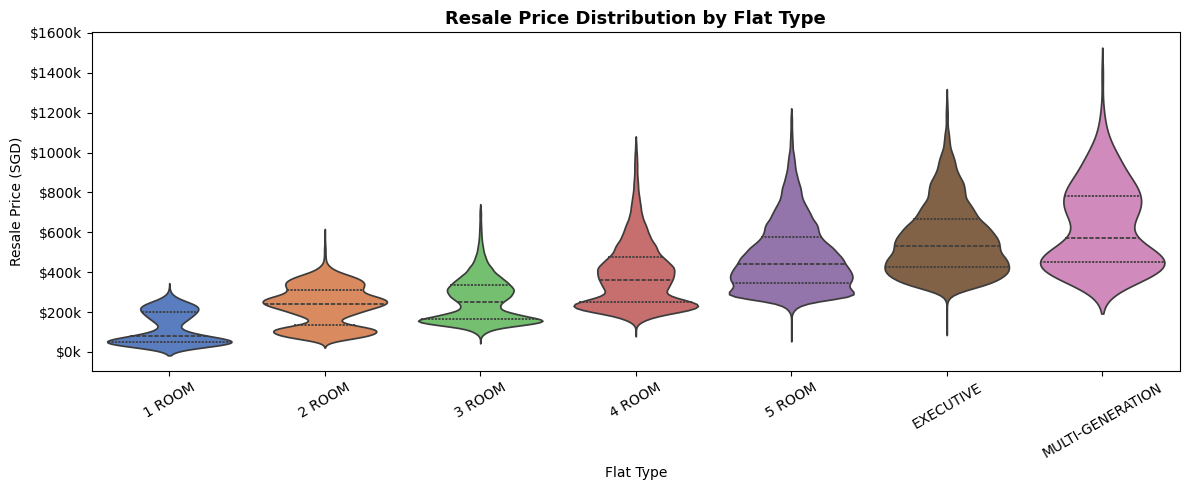

/tmp/ipykernel_598/141292347.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dist_pdf[dist_pdf["town"].isin(top10)], x="town", y="resale_price",


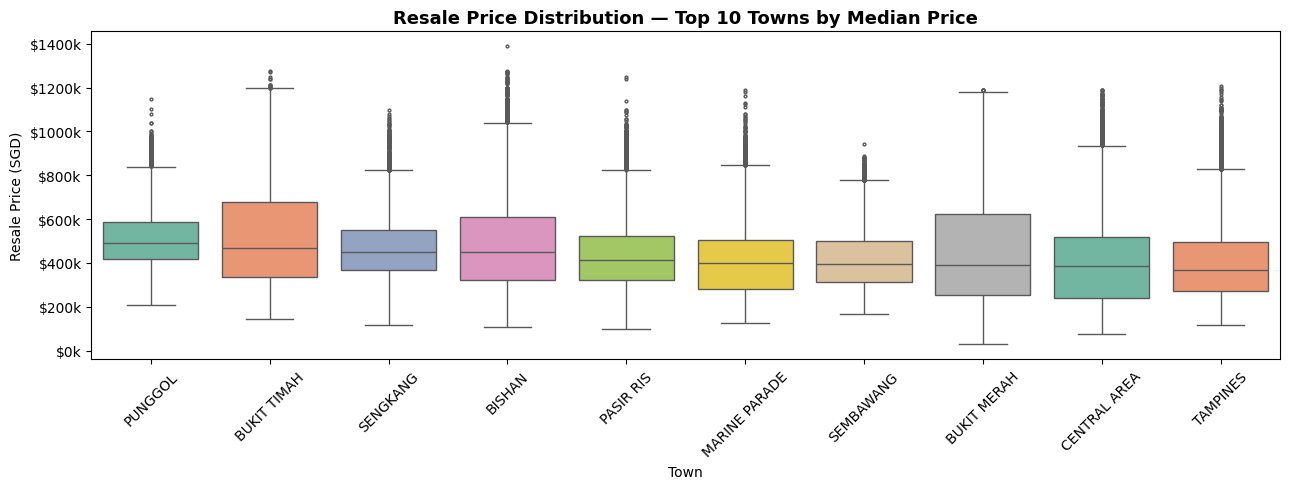

In [48]:
# ── EDA 2: Price distribution by flat type & town ──
dist_pdf = (
    df.filter(~F.col("resale_price_outlier"))
      .select("resale_price", "flat_type", "town")
      .toPandas()
)

# Violin by flat_type
fig, ax = plt.subplots(figsize=(12, 5))
order = dist_pdf.groupby("flat_type")["resale_price"].median().sort_values().index
sns.violinplot(data=dist_pdf, x="flat_type", y="resale_price",
               order=order, palette="muted", ax=ax, inner="quartile")
ax.set_title("Resale Price Distribution by Flat Type", fontsize=13, fontweight="bold")
ax.set_xlabel("Flat Type")
ax.set_ylabel("Resale Price (SGD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# Box by top-10 towns
top10 = dist_pdf.groupby("town")["resale_price"].median().nlargest(10).index
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=dist_pdf[dist_pdf["town"].isin(top10)], x="town", y="resale_price",
            order=top10, palette="Set2", ax=ax, flierprops={"markersize": 2})
ax.set_title("Resale Price Distribution — Top 10 Towns by Median Price",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Town")
ax.set_ylabel("Resale Price (SGD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

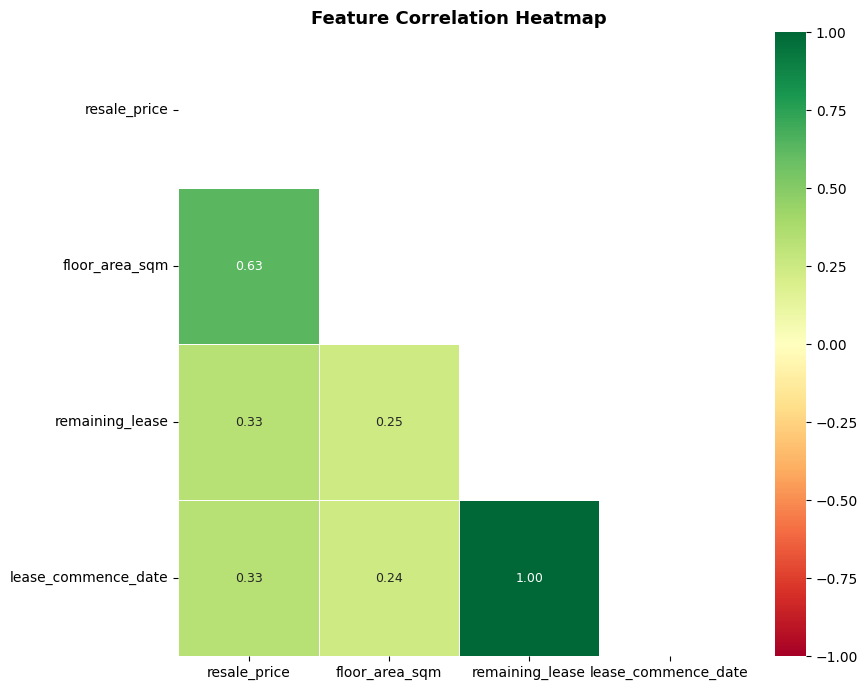


  Correlations with resale_price (absolute, descending):
floor_area_sqm         0.631174
remaining_lease        0.332689
lease_commence_date    0.330994


In [53]:
# ── EDA 3: Correlation heatmap ──
corr_cols = [c for c in ["resale_price", "floor_area_sqm",
                          "remaining_lease", "lease_commence_date"
                        ]
             if c in df.columns]

corr_pdf = df.select(corr_cols).dropna().limit(50_000).toPandas()
corr_mat = corr_pdf.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n  Correlations with resale_price (absolute, descending):")
print(
    corr_mat["resale_price"]
    .drop("resale_price")
    .abs()
    .sort_values(ascending=False)
    .to_string()
)

End

In [57]:
spark.stop()
print('Spark session stopped.')

Spark session stopped.
